# CSW 프로젝트 EDA ①: 데이터 가져오기 → 투수의 수

> **데이터**: `data/statcast_2017_2019_raw_csw.parquet` — 2017–2019 MLB Statcast 투구 단위 원본 + CSW 라벨 (2,201,095행 × 122열)
> **실행 위치**: 프로젝트 루트 (이 노트북이 있는 폴더). `data/` 폴더가 옆에 있어야 함.

**흐름** — 각 단계는 앞 단계의 결과를 확인하고 나서 넘어갑니다.

1. **데이터 가져오기**: 파일 확인(manifest) → 스키마 훑기 → 필요한 열만 로드 → 검증
2. **EDA — 투수의 수**: 시즌별 투수 수 → 투수당 투구 수 분포 → 집중도 → 최소 표본 기준 → 시즌 간 겹침

**왜 '투수의 수'부터?** CSW 모델의 핵심 피처(커맨드 `cmd_ff_*`, CSW 이력)와 Kirby Index는 전부
**투수별 과거 표본**에서 계산됩니다. 투수당 투구가 몇 개나 쌓이는지가 모든 후속 분석의 전제 조건입니다.

## 0. 환경 준비

없는 패키지만 골라 설치하므로 반복 실행해도 무해합니다.

In [1]:
# 필요한 패키지가 없을 때만 설치
import importlib.util, subprocess, sys

for pkg in ['pandas', 'numpy', 'pyarrow', 'matplotlib']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
print('패키지 준비 완료')

패키지 준비 완료


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# 한글 폰트: OS별로 있는 것을 자동 선택 (Windows=맑은 고딕)
def set_korean_font():
    from matplotlib import font_manager
    names = {f.name for f in font_manager.fontManager.ttflist}
    for cand in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'NanumBarunGothic']:
        if cand in names:
            matplotlib.rcParams['font.family'] = cand
            return cand
    return None  # 못 찾으면 그래프의 한글이 □로 보일 수 있음 (분석에는 영향 없음)

font = set_korean_font()
matplotlib.rcParams['axes.unicode_minus'] = False
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

DATA_PATH = Path('data/statcast_2017_2019_raw_csw.parquet')
MANIFEST_PATH = Path('data/statcast_raw_sequence/manifest.csv')
assert DATA_PATH.exists(), f'{DATA_PATH} 없음 — 프로젝트 루트에서 실행했는지 확인'
assert MANIFEST_PATH.exists(), f'{MANIFEST_PATH} 없음'
print(f'폰트: {font} | 데이터 파일 확인 완료')

폰트: NanumGothic | 데이터 파일 확인 완료


## 1. 데이터 가져오기

### 1-1. 무엇을 받았는지부터 — manifest(수집 영수증) 확인

원본은 월별 22개 청크로 수집됐고, 각 청크의 기간·행 수가 `manifest.csv`에 기록돼 있습니다.
통합 파일을 열기 전에 **"몇 행이 들어 있어야 정상인지"** 기대값을 먼저 만들어 둡니다.

In [3]:
manifest = pd.read_csv(MANIFEST_PATH)

by_season = (manifest.groupby('season')
             .agg(청크수=('chunk_order', 'count'),
                  시작일=('start_date', 'min'),
                  종료일=('end_date', 'max'),
                  행수=('row_count', 'sum')))
EXPECTED_ROWS = int(manifest['row_count'].sum())

print(f'기대 총 행 수 = {EXPECTED_ROWS:,}')
by_season

기대 총 행 수 = 2,201,095


,청크수,시작일,종료일,행수
season,,,,
2017,7,2017-04-02,2017-10-01,724627
2018,8,2018-03-29,2018-10-01,724452
2019,7,2019-03-20,2019-09-29,752016


### 1-2. 파일을 열지 않고 구조 보기 — parquet 메타데이터

parquet은 파일 끝에 스키마(행 수·열 목록)가 저장돼 있어 **데이터를 읽지 않고도** 구조를 확인할 수 있습니다.
251MB 파일이지만 이 셀은 즉시 끝납니다.

In [4]:
import pyarrow.parquet as pq

pf = pq.ParquetFile(DATA_PATH)
n_rows, n_cols = pf.metadata.num_rows, pf.metadata.num_columns
all_cols = pf.schema_arrow.names

print(f'행 수: {n_rows:,} (manifest 기대값과 일치: {n_rows == EXPECTED_ROWS})')
print(f'열 수: {n_cols}')
print(f"라벨 is_csw 존재: {'is_csw' in all_cols}")
print()
print('열 목록 (앞 30개):')
print(all_cols[:30])

행 수: 2,201,095 (manifest 기대값과 일치: True)
열 수: 122
라벨 is_csw 존재: True

열 목록 (앞 30개):
['_sequence_in_chunk', '_source_row', 'pitch_type', 'game_date', 'release_speed', 'release_pos_x', 'release_pos_z', 'player_name', 'batter', 'pitcher', 'events', 'description', 'spin_dir', 'spin_rate_deprecated', 'break_angle_deprecated', 'break_length_deprecated', 'zone', 'des', 'game_type', 'stand', 'p_throws', 'home_team', 'away_team', 'type', 'hit_location', 'bb_type', 'balls', 'strikes', 'game_year', 'pfx_x']


### 1-3. 필요한 열만 골라 로드

122열을 전부 읽으면 메모리를 수 GB 쓰지만, **투수의 수** 분석에는 아래 9개면 충분합니다.
parquet은 열 단위 저장이라 필요한 열만 골라 읽으면 로드도 훨씬 빠릅니다.

| 열 | 의미 | 쓰임 |
|---|---|---|
| `game_year` | 시즌 | 시즌별 집계 |
| `game_date` | 경기 날짜 | 시간 범위 검증 |
| `game_pk` | 경기 고유 ID | 경기 수 집계 |
| `game_type` | 경기 유형 (R=정규시즌) | 데이터 구성 확인 |
| `pitcher` | 투수 MLBAM ID | **핵심 키** |
| `player_name` | 투수 이름 | 표에서 읽기 좋게 |
| `p_throws` | 투수 좌/우 | 구성 확인 |
| `pitch_type` | 구종 코드 | FF(포심) 표본 기준 |
| `is_csw` | CSW 라벨 (0/1) | 라벨 분포 검증 |

In [5]:
USE_COLS = ['game_year', 'game_date', 'game_pk', 'game_type',
            'pitcher', 'player_name', 'p_throws', 'pitch_type', 'is_csw']

df = pd.read_parquet(DATA_PATH, columns=USE_COLS)
df['game_date'] = pd.to_datetime(df['game_date'])

mem_before = df.memory_usage(deep=True).sum() / 1e6
# 반복되는 문자열 열은 category로 바꾸면 메모리가 크게 줄어듦
for c in ['game_type', 'p_throws', 'pitch_type', 'player_name']:
    df[c] = df[c].astype('category')
mem_after = df.memory_usage(deep=True).sum() / 1e6

print(f'로드: {len(df):,}행 × {df.shape[1]}열')
print(f'메모리: {mem_before:,.0f} MB → category 변환 후 {mem_after:,.0f} MB')
df.head()

로드: 2,201,095행 × 9열
메모리: 624 MB → category 변환 후 90 MB


,game_year,game_date,game_pk,game_type,pitcher,player_name,p_throws,pitch_type,is_csw
0,2017,2017-04-02,490099,R,593372,"Martinez, Carlos",R,FF,0
1,2017,2017-04-02,490099,R,593372,"Martinez, Carlos",R,SI,0
2,2017,2017-04-02,490099,R,593372,"Martinez, Carlos",R,SI,0
3,2017,2017-04-02,490099,R,593372,"Martinez, Carlos",R,SL,0
4,2017,2017-04-02,490099,R,593372,"Martinez, Carlos",R,SI,1


### 1-4. 검증 — 제대로 가져왔나

로드 직후 항상 확인하는 4가지: ① 행 수가 기대값과 일치하는가 ② 시즌별로도 일치하는가
③ 핵심 열에 결측이 없는가 ④ 라벨 분포가 알려진 값(시즌 CSW율 약 27%)과 맞는가.

In [6]:
season_rows = df.groupby('game_year').size()
manifest_rows = manifest.groupby('season')['row_count'].sum()

checks = pd.DataFrame([
    ('총 행 수 = manifest 합계',
     len(df) == EXPECTED_ROWS, f'{len(df):,}'),
    ('시즌별 행 수 = manifest 시즌 합계',
     bool((season_rows.values == manifest_rows.values).all()),
     ' / '.join(f'{y}: {n:,}' for y, n in season_rows.items())),
    ('핵심 열(pitcher, game_year, is_csw) 결측 0',
     df[['pitcher', 'game_year', 'is_csw']].isna().sum().sum() == 0,
     f"전체 결측: pitch_type {df['pitch_type'].isna().sum():,}건 정도만 존재"),
    ('CSW율이 상식 범위(25~30%)',
     0.25 < df['is_csw'].mean() < 0.30, f"{df['is_csw'].mean():.1%}"),
], columns=['점검', '통과', '값'])

assert checks['통과'].all(), '검증 실패 항목 있음!'
print('경기 유형 구성:', dict(df['game_type'].value_counts()))
print(f"기간: {df['game_date'].min().date()} ~ {df['game_date'].max().date()}")
checks

경기 유형 구성: {'R': np.int64(2184169), 'S': np.int64(16926)}
기간: 2017-04-02 ~ 2019-09-29


,점검,통과,값
0,총 행 수 = manifest 합계,True,"2,201,095"
1,시즌별 행 수 = manifest 시즌 합계,True,"2017: 724,627 / 2018: 724,452 / 2019: 752,016"
2,"핵심 열(pitcher, game_year, is_csw) 결측 0",True,"전체 결측: pitch_type 30,659건 정도만 존재"
3,CSW율이 상식 범위(25~30%),True,27.4%


---
## 2. EDA — 투수의 수

### 2-1. 시즌별로 투수가 몇 명이나 등판했나

MLB 30개 팀이 시즌당 700명대의 투수를 씁니다. 먼저 규모 감을 잡습니다.

3시즌 전체 고유 투수: 1,403명


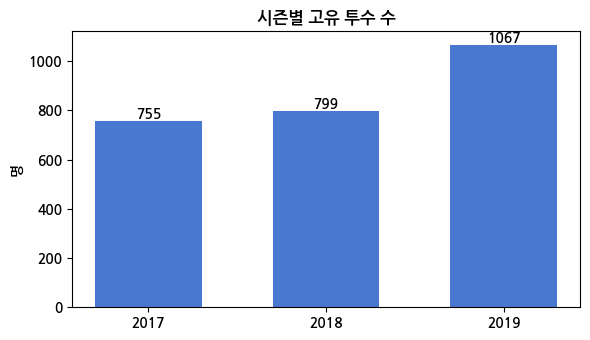

,투구수,투수수,경기수,투수당 평균,투수당 중앙값
game_year,,,,,
2017,724627,755,2430,960.000,773.000
2018,724452,799,2431,907.000,676.000
2019,752016,1067,2527,705.000,394.000


In [7]:
season_tbl = (df.groupby('game_year')
              .agg(투구수=('pitcher', 'size'),
                   투수수=('pitcher', 'nunique'),
                   경기수=('game_pk', 'nunique')))
season_tbl['투수당 평균'] = (season_tbl['투구수'] / season_tbl['투수수']).round(0)
season_tbl['투수당 중앙값'] = (df.groupby(['game_year', 'pitcher'], observed=True).size()
                            .groupby('game_year').median())

n_total = df['pitcher'].nunique()
print(f'3시즌 전체 고유 투수: {n_total:,}명')

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(season_tbl.index.astype(str), season_tbl['투수수'], color='#4878cf', width=0.6)
ax.bar_label(bars, fmt='%d')
ax.set_title('시즌별 고유 투수 수')
ax.set_ylabel('명')
plt.tight_layout(); plt.show()

season_tbl

**읽는 법**: 평균(2,000구 안팎)보다 중앙값이 훨씬 낮다면, 소수의 풀타임 투수와 다수의 짧은 등판 투수가
섞여 있다는 뜻입니다. 다음 셀에서 분포로 직접 확인합니다.

### 2-2. 투수 한 명이 시즌에 몇 구나 던지나 — 분포

투수별 이력 피처(rolling 40구, last100 등)가 의미 있으려면 표본이 충분해야 합니다.

,count,min,25%,50%,75%,max
game_year,,,,,,
2017,755,5,264,773,1210,3546
2018,799,2,215,676,1188,3503
2019,1067,1,29,394,1037,3742


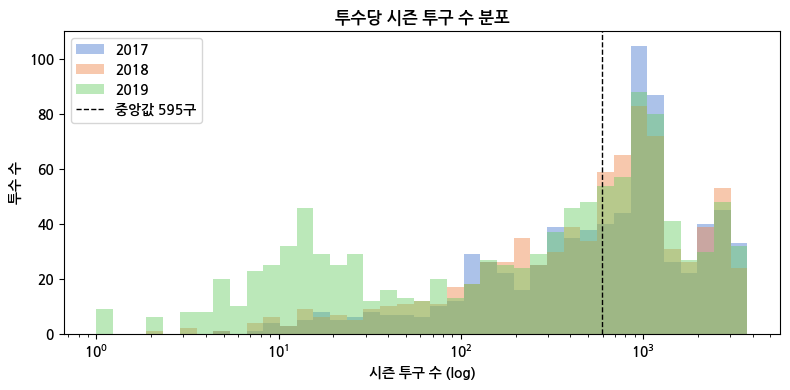

,game_year,pitcher,player_name,투구수
0,2019,545333,"Bauer, Trevor",3742
1,2019,458681,"Lynn, Lance",3585
2,2017,434378,"Verlander, Justin",3546
3,2019,593958,"Rodriguez, Eduardo",3518
4,2018,453286,"Scherzer, Max",3503
5,2017,519242,"Sale, Chris",3428
6,2018,434378,"Verlander, Justin",3427
7,2017,502042,"Archer, Chris",3406
8,2018,572971,"Keuchel, Dallas",3310


In [8]:
# 시즌×투수 단위 투구 수 (한 투수가 3시즌 던지면 3개 표본)
ppp = df.groupby(['game_year', 'pitcher'], observed=True).size().rename('투구수')

desc = (ppp.groupby('game_year')
        .describe()[['count', 'min', '25%', '50%', '75%', 'max']]
        .astype(int))
display(desc)

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.logspace(0, np.log10(ppp.max()), 40)
for yr, color in zip([2017, 2018, 2019], ['#4878cf', '#ee854a', '#6acc64']):
    ax.hist(ppp.loc[yr], bins=bins, alpha=0.45, label=str(yr), color=color)
ax.axvline(ppp.median(), color='k', ls='--', lw=1,
           label=f'중앙값 {ppp.median():.0f}구')
ax.set_xscale('log')
ax.set_xlabel('시즌 투구 수 (log)')
ax.set_ylabel('투수 수')
ax.set_title('투수당 시즌 투구 수 분포')
ax.legend()
plt.tight_layout(); plt.show()

# 시즌별 최다 투구 투수
top = (df.groupby(['game_year', 'pitcher', 'player_name'], observed=True).size()
       .rename('투구수').reset_index()
       .sort_values('투구수', ascending=False)
       .groupby('game_year').head(3).reset_index(drop=True))
top

### 2-3. 투구가 소수 투수에게 얼마나 몰려 있나 — 집중도

투수를 투구 수 순으로 줄 세웠을 때, 상위 몇 %가 전체 투구의 몇 %를 차지하는지 봅니다.
이 곡선이 가파를수록 "리그 전체 투구의 대부분은 표본 많은 투수의 것"이라 투수별 이력 피처가 잘 작동합니다.

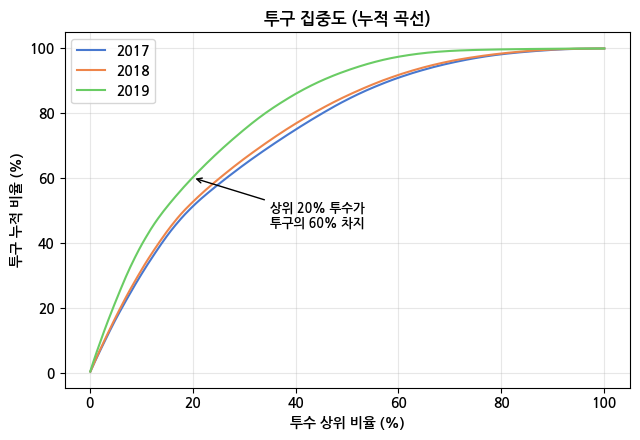

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
for yr, color in zip([2017, 2018, 2019], ['#4878cf', '#ee854a', '#6acc64']):
    s = ppp.loc[yr].sort_values(ascending=False)
    x = np.arange(1, len(s) + 1) / len(s)
    y = s.cumsum() / s.sum()
    ax.plot(x * 100, y * 100, label=str(yr), color=color)
    if yr == 2019:
        cov20 = y.iloc[int(len(s) * 0.2) - 1] * 100
        ax.annotate(f'상위 20% 투수가\n투구의 {cov20:.0f}% 차지',
                    xy=(20, cov20), xytext=(35, 45),
                    arrowprops=dict(arrowstyle='->'), fontsize=9)
ax.set_xlabel('투수 상위 비율 (%)')
ax.set_ylabel('투구 누적 비율 (%)')
ax.set_title('투구 집중도 (누적 곡선)')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()

### 2-4. 최소 표본 기준을 걸면 투수가 몇 명 남나

분석마다 최소 표본 기준이 다릅니다 — Kirby Index는 **포심(FF) 125구**, cmd 피처는 rolling 40구,
CSW 이력은 last100. 기준을 올릴수록 투수 수는 줄지만 남는 투수가 전체 투구의 대부분을 커버하면 문제없습니다.

,시즌×투수 수,시즌당 평균 투수,투구 커버리지
기준(구),,,
1,2621,874,100.0%
50,2194,731,99.6%
125,2015,672,98.9%
300,1694,565,96.0%
500,1417,472,91.1%
1000,836,279,71.0%
2000,344,115,42.1%


정규시즌 FF 125구 이상: 시즌×투수 1,397건  (reports/kirby_index_by_season.csv의 1,397건과 일치해야 정상)


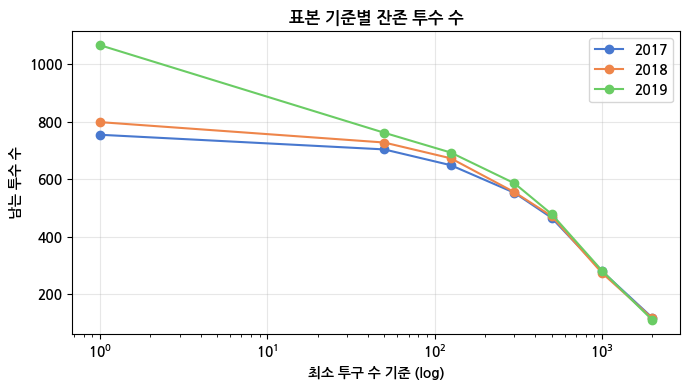

In [10]:
thresholds = [1, 50, 125, 300, 500, 1000, 2000]
rows = []
for t in thresholds:
    keep = ppp[ppp >= t]
    rows.append({'기준(구)': t,
                 '시즌×투수 수': len(keep),
                 '시즌당 평균 투수': round(len(keep) / 3),
                 '투구 커버리지': f'{keep.sum() / ppp.sum():.1%}'})
thr_tbl = pd.DataFrame(rows).set_index('기준(구)')
display(thr_tbl)

# Kirby Index 기준 교차 확인: 정규시즌 FF 125구 이상
ff = df[(df['pitch_type'] == 'FF') & (df['game_type'] == 'R')]
ff_ppp = ff.groupby(['game_year', 'pitcher'], observed=True).size()
n_kirby = int((ff_ppp >= 125).sum())
print(f'정규시즌 FF 125구 이상: 시즌×투수 {n_kirby:,}건'
      f'  (reports/kirby_index_by_season.csv의 1,397건과 일치해야 정상)')

fig, ax = plt.subplots(figsize=(7, 4))
counts = [(ppp.loc[yr].to_numpy() >= np.array(thresholds)[:, None]).sum(axis=1)
          for yr in [2017, 2018, 2019]]
for yr, c, color in zip([2017, 2018, 2019], counts, ['#4878cf', '#ee854a', '#6acc64']):
    ax.plot(thresholds, c, 'o-', label=str(yr), color=color)
ax.set_xscale('log')
ax.set_xlabel('최소 투구 수 기준 (log)')
ax.set_ylabel('남는 투수 수')
ax.set_title('표본 기준별 잔존 투수 수')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()

### 2-5. 시즌이 바뀌어도 같은 투수가 얼마나 남나

시즌 간 겹치는 투수가 stickiness 분석(2017→18→19 상관)과 "과거 시즌 이력 피처"의 표본이 됩니다.

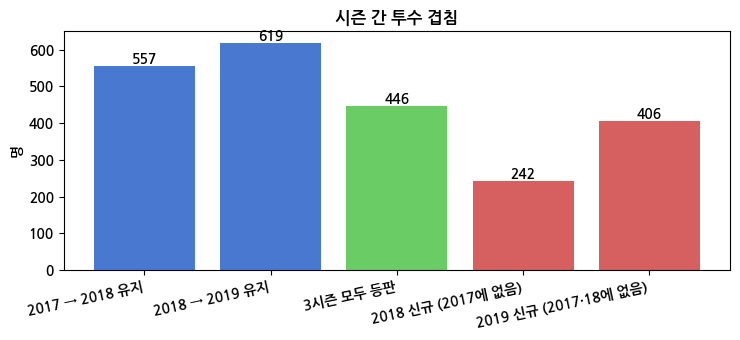

,구분,투수 수,비율
0,2017 → 2018 유지,557,74% (2017 기준)
1,2018 → 2019 유지,619,77% (2018 기준)
2,3시즌 모두 등판,446,32% (전체 투수 기준)
3,2018 신규 (2017에 없음),242,
4,2019 신규 (2017·18에 없음),406,


In [11]:
sets = {yr: set(df.loc[df['game_year'] == yr, 'pitcher'].unique())
        for yr in [2017, 2018, 2019]}

overlap = pd.DataFrame([
    ('2017 → 2018 유지', len(sets[2017] & sets[2018]),
     f'{len(sets[2017] & sets[2018]) / len(sets[2017]):.0%} (2017 기준)'),
    ('2018 → 2019 유지', len(sets[2018] & sets[2019]),
     f'{len(sets[2018] & sets[2019]) / len(sets[2018]):.0%} (2018 기준)'),
    ('3시즌 모두 등판', len(sets[2017] & sets[2018] & sets[2019]),
     f'{len(sets[2017] & sets[2018] & sets[2019]) / n_total:.0%} (전체 투수 기준)'),
    ('2018 신규 (2017에 없음)', len(sets[2018] - sets[2017]), ''),
    ('2019 신규 (2017·18에 없음)', len(sets[2019] - sets[2018] - sets[2017]), ''),
], columns=['구분', '투수 수', '비율'])

fig, ax = plt.subplots(figsize=(7.5, 3.5))
bars = ax.bar(overlap['구분'], overlap['투수 수'],
              color=['#4878cf', '#4878cf', '#6acc64', '#d65f5f', '#d65f5f'])
ax.bar_label(bars)
ax.set_ylabel('명')
ax.set_title('시즌 간 투수 겹침')
plt.xticks(rotation=12, ha='right')
plt.tight_layout(); plt.show()

overlap

---
## 3. 정리와 다음 단계

**이 노트북에서 확인한 것**

- 데이터 가져오기: manifest 기대값 → 스키마 → 열 9개 선택 로드 → 4종 검증 통과. 이후 노트북도 같은 패턴을 쓰면 됩니다.
- 투수의 수: 시즌당 700명대가 등판하지만 분포가 극도로 비대칭 — 투구의 대부분은 상위 투수 몫이라, 투수별 rolling/이력 피처가 리그 전체 투구의 대다수에서 유효합니다.
- 표본 기준표(2-4)는 회의 안건인 cmd window(40구)·csw 이력 window(100구) 튜닝의 근거 자료로 사용.
- 시즌 간 겹침(2-5)이 stickiness 표본 크기의 상한.

**다음 노트북 후보 (EDA ②)**

1. 투수별 CSW율 vs 표본 크기 — 소표본 투수의 CSW율이 얼마나 불안정한지 (shrinkage 필요성)
2. 선발/불펜 근사 구분(1회 등판 여부)별 투수 수·투구 수·CSW율 비교
3. 구종 구성: 투수당 구종 수와 FF 비중 (Kirby 확장 E단계와 연결)